In [2]:
import numpy as np
from scipy.signal import butter, filtfilt, convolve
import matplotlib.pyplot as plt

# Set up time vector and the laser signal

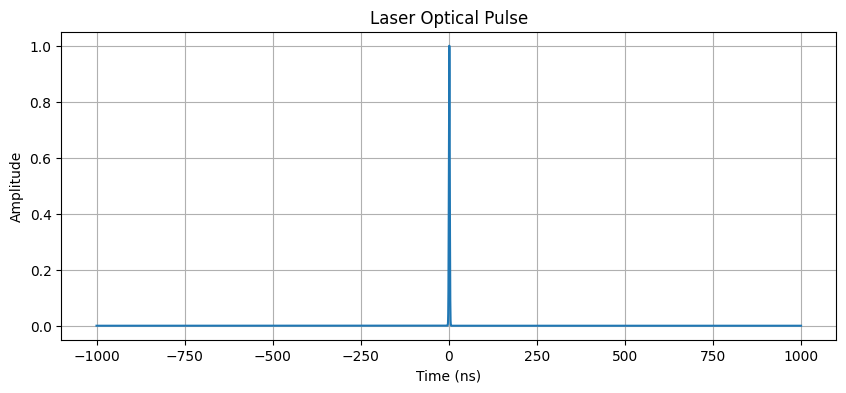

In [3]:
# time vector
dt_ns = 0.1
t = np.arange(-1000, 1000, dt_ns)  # time vector from 0 to 100 ns with 0.1 ns step

# laser optical pulse
pulse_width = 3 # pulse duration in ns

laser_signal = np.zeros_like(t)
laser_signal = np.exp(-4 * np.log(2) * (t - pulse_width / 2) ** 2 / pulse_width ** 2) # gaussian pulse with FWHM equal to pulse_width
# laser_signal = np.where((t >= 0) & (t <= pulse_width), 1, 0)  # square pulse with duration equal to pulse_width

# plot the laser signal
plt.figure(figsize=(10, 4))
plt.plot(t, laser_signal, label='Laser Optical Pulse')
plt.title('Laser Optical Pulse')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# PMT response

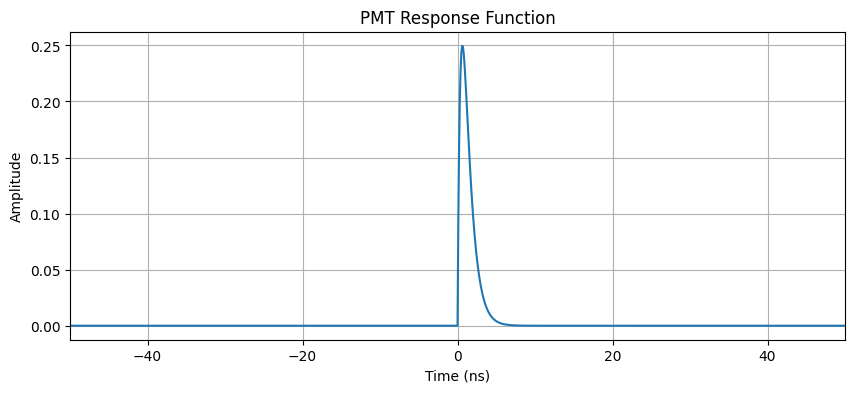

In [4]:
t_rise = 1 # rise time in ns
t_fall = 2 # fall time in ns

pmt_response = np.zeros_like(t)
#pmt_response[t >= 0] = (1 - np.exp(-t[t >= 0] / t_rise)) * np.exp(-t[t >= 0] / t_fall)

# difference of exponentials response
tau_rise = t_rise / 2.2  # convert rise time to time constant
tau_fall = t_fall / 2.2  # convert fall time to time constant
pmt_response[t >= 0] = (np.exp(-t[t >= 0] / tau_fall) - np.exp(-t[t >= 0] / tau_rise))

# plot the PMT response
plt.figure(figsize=(10, 4))
plt.plot(t, pmt_response, label='PMT Response')
plt.title('PMT Response Function')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.xlim(-50, 50)
plt.grid()
plt.show()

# RF amplifier BPF

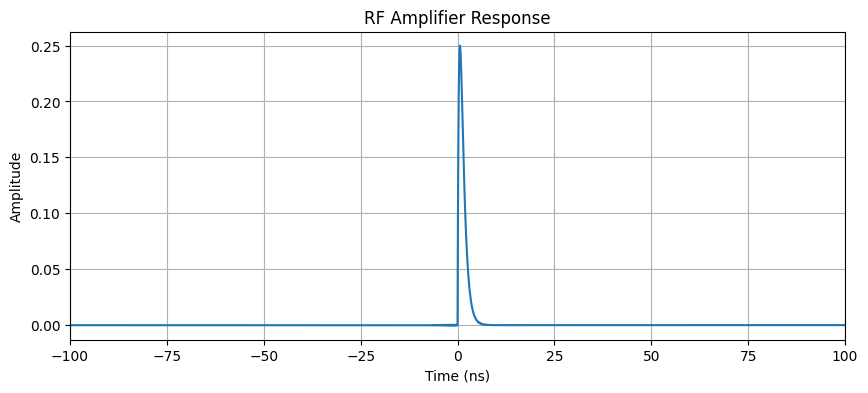

In [5]:
# RF amplifier with 20MHz-8GHz bandwidth

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

lowcut = 0.1e6  # 20 MHz
highcut = 8e9  # 8 GHz
fs_hz = 1 / (dt_ns * 1e-9)
nyquist_hz = 0.5 * fs_hz
highcut_eff = min(highcut, 0.99 * nyquist_hz)
b, a = butter_bandpass(lowcut, highcut_eff, fs_hz)

amplifier_response = np.zeros_like(t)
amplifier_response = filtfilt(b, a, pmt_response)
# plot the amplifier response
plt.figure(figsize=(10, 4))
plt.plot(t, amplifier_response, label='Amplifier Response')
plt.title('RF Amplifier Response')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.xlim(-100, 100)
plt.grid()

# Scope Responses

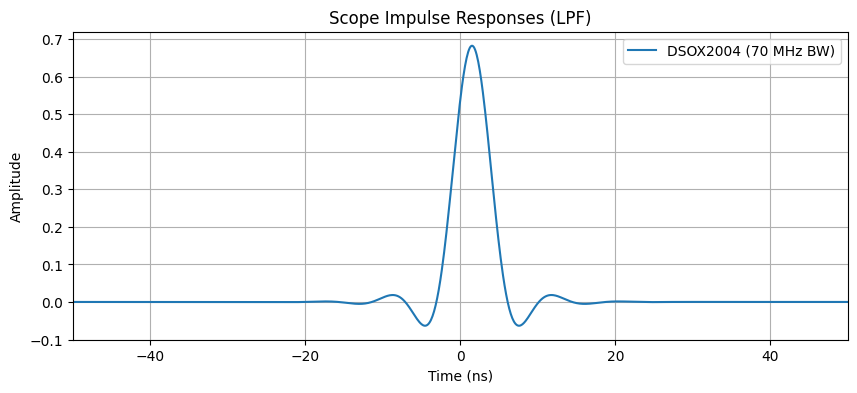

In [6]:
# DSOX2004 - agilent
#BW = 70_000_000  # bandwidth in Hz
# measured bandwidth is closer to 110MHz
BW = 125_000_000

scope_response = np.zeros_like(t)

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, cutoff, fs, order=4):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

fs_hz = 1 / (dt_ns * 1e-9)
scope_response = butter_lowpass_filter(laser_signal, BW, fs_hz)

# plot the scope responses
plt.figure(figsize=(10, 4))
plt.plot(t, scope_response, label='DSOX2004 (70 MHz BW)')
plt.title('Scope Impulse Responses (LPF)')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.xlim(-50, 50)
plt.grid()
plt.legend()
plt.show()

# Convolve the system

10% pulse width of system response: 8.50 ns


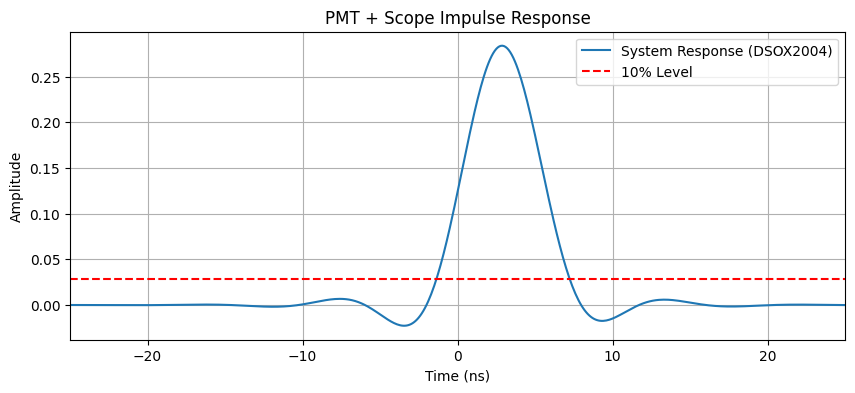

In [7]:
# find the transfer funciton of     ---> pmt * amplifier * scope_response_1 --->
# this gives the system response to a laser input which is a perfect impulse.
dt = dt_ns * 1e-9
system_response = convolve(pmt_response, scope_response, mode='same') * dt_ns  # scale by the time step
#system_response = convolve(system_response, amplifier_response, mode='same') * dt_ns

# find the 10% pulse width of the system response
response_peak = np.max(system_response)
response_10_percent = 0.1 * response_peak
indices_above_10_percent = np.where(system_response >= response_10_percent)[0]
if len(indices_above_10_percent) > 0:
    pulse_width_10_percent = (indices_above_10_percent[-1] - indices_above_10_percent[0]) * dt_ns
    print(f"10% pulse width of system response: {pulse_width_10_percent:.2f} ns")

# plot the system response
plt.figure(figsize=(10, 4))
plt.plot(t, system_response, label='System Response (DSOX2004)')
# plot the 10% level
plt.axhline(response_10_percent, color='red', linestyle='--', label='10% Level')
plt.xlim(-25, 25)
plt.title('PMT + Scope Impulse Response')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()



# System output from laser

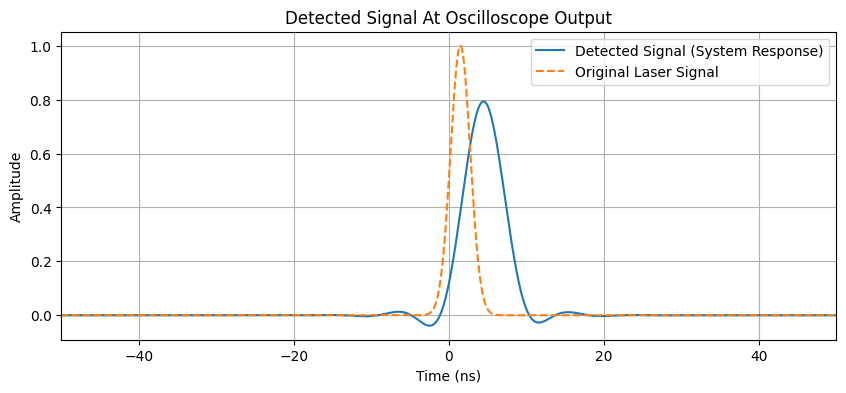

In [8]:
system_output = convolve(laser_signal, system_response, mode='same') * dt_ns

# plot the detected signal
plt.figure(figsize=(10, 4))
plt.plot(t, system_output, label='Detected Signal (System Response)')
plt.plot(t, laser_signal, label='Original Laser Signal', linestyle='--')
plt.xlim(-50, 50)  # zoom in around the pulse
plt.title('Detected Signal At Oscilloscope Output')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

# Deconvolution

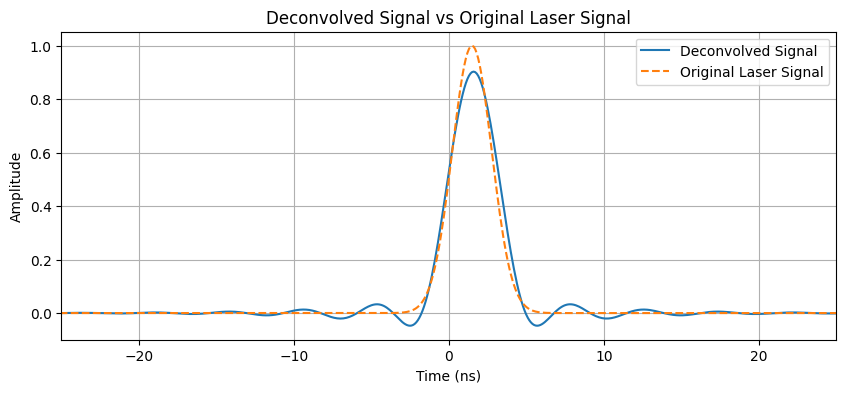

In [9]:


# attempt to deconvolve the scope response from the scope output to recover the laser signal using Wiener deconvolution
def wiener_deconvolution(signal, kernel, noise_power, sample_spacing):
    signal_centered = np.fft.ifftshift(signal)
    kernel_centered = np.fft.ifftshift(kernel)

    signal_fft = np.fft.fft(signal_centered)
    kernel_fft = np.fft.fft(kernel_centered, n=len(signal)) * sample_spacing
    kernel_power = np.abs(kernel_fft) ** 2
    wiener_filter = np.conj(kernel_fft) / (kernel_power + noise_power)
    deconvolved_fft = signal_fft * wiener_filter
    deconvolved_signal = np.fft.ifft(deconvolved_fft)
    return np.fft.fftshift(np.real(deconvolved_signal))
noise_power = 0.00001  # assume some noise power

deconvolved_signal = wiener_deconvolution(system_output, system_response, noise_power, dt_ns)

# plot the deconvolved signal
plt.figure(figsize=(10, 4))
plt.plot(t, deconvolved_signal, label='Deconvolved Signal')
plt.plot(t, laser_signal, label='Original Laser Signal', linestyle='--')
plt.xlim(-25, 25)  # zoom in around the pulse
plt.title('Deconvolved Signal vs Original Laser Signal')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()

# Test deconvolution

the impulse response is captured as the result of a single photon detection.
The laser signal was then measured and the impulse response will be used to deconvolve the laser signal.

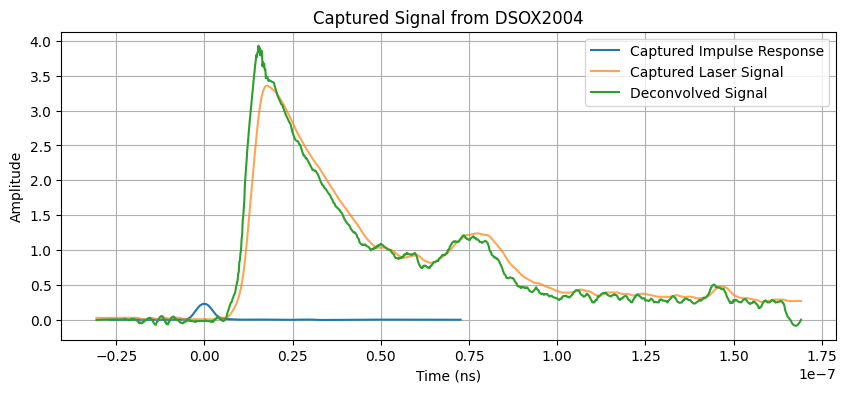

In [50]:
import csv
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import windows


def prepare_uniform_trace(trace, dt=None, t_min=None, t_max=None):
    """
    trace: Nx2 array [time, amplitude]
    returns t_uniform, y_uniform
    """
    t = trace[:, 0].astype(float)
    y = trace[:, 1].astype(float)

    # Sort by time
    idx = np.argsort(t)
    t, y = t[idx], y[idx]

    if dt is None:
        dt = np.median(np.diff(t))

    if t_min is None:
        t_min = t[0]
    if t_max is None:
        t_max = t[-1]

    t_uniform = np.arange(t_min, t_max, dt)

    f = interp1d(t, y, kind="linear", bounds_error=False, fill_value=0.0)
    y_uniform = f(t_uniform)

    return t_uniform, y_uniform



def load_scope_csv(path, usecols=(0, 1), skip_rows=2):
    rows = []
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            if len(row) <= max(usecols):
                continue
            values = [row[index].strip() for index in usecols]
            if any(value == "" for value in values):
                continue
            rows.append(values)

    data = np.array(rows[skip_rows:], dtype=float)
    return data



def wiener_deconvolve_different_timebases(
    signal_trace,
    impulse_trace,
    dt=None,
    noise=1e-3,
    baseline_fraction=0.1,
    pad_factor=4,
):
    """
    signal_trace:  Nx2 array [time, measured signal]
    impulse_trace: Mx2 array [time, measured impulse response]
    dt: common timestep. If None, uses the smaller median dt of the two traces.
    noise: Wiener regularisation parameter. Larger = smoother / less ringing.
    baseline_fraction: fraction of start of trace used for baseline subtraction.
    pad_factor: zero-padding factor to reduce circular convolution artefacts.

    Returns:
        t_common, deconvolved, measured_uniform, impulse_uniform
    """

    # Choose common dt
    dt_signal = np.median(np.diff(np.sort(signal_trace[:, 0])))
    dt_impulse = np.median(np.diff(np.sort(impulse_trace[:, 0])))

    if dt is None:
        dt = min(dt_signal, dt_impulse)

    # Use signal time range as output range
    t_min = signal_trace[:, 0].min()
    t_max = signal_trace[:, 0].max()

    t, y = prepare_uniform_trace(signal_trace, dt=dt, t_min=t_min, t_max=t_max)

    # Put impulse on same grid, centred around its own pulse
    ti = impulse_trace[:, 0]
    hi = impulse_trace[:, 1]

    # Baseline subtract
    n_base_y = max(5, int(len(y) * baseline_fraction))
    y = y - np.mean(y[:n_base_y])

    n_base_h = max(5, int(len(hi) * baseline_fraction))
    hi = hi - np.mean(hi[:n_base_h])

    # Align impulse peak to t=0
    peak_idx = np.argmax(np.abs(hi))
    ti0 = ti - ti[peak_idx]

    # Resample impulse onto same relative grid length as signal
    h_rel = np.arange(0, len(t) * dt, dt)

    interp_h = interp1d(ti0, hi, kind="linear", bounds_error=False, fill_value=0.0)
    h = interp_h(h_rel)

    # Normalise impulse response area so convolution units behave sensibly
    area = np.sum(h) * dt
    if abs(area) > 1e-30:
        h = h / area
    else:
        # fallback: normalise peak if area is near zero due to bipolar ringing
        h = h / np.max(np.abs(h))

    # Optional window to soften hard edges
    y = y * windows.tukey(len(y), alpha=0.05)

    # Zero pad
    n = len(y)
    n_fft = int(2 ** np.ceil(np.log2(pad_factor * n)))

    Y = np.fft.fft(y, n_fft)
    H = np.fft.fft(h, n_fft) * dt

    # Wiener filter
    H_power = np.abs(H) ** 2
    X_est = Y * np.conj(H) / (H_power + noise)

    x = np.real(np.fft.ifft(X_est))[:n]

    return t, x, y, h


# impulse response:
impulse_response = load_scope_csv("./scope captures/single photon good socket averaged.csv")
# invert the signal so the pulse is positive
impulse_response[:, 1] = -impulse_response[:, 1]


# laser signal:
signal = load_scope_csv("./scope captures/open laser beam dump.csv", usecols=(0, 1))
# invert the signal so the pulse is positive
signal[:, 1] = -signal[:, 1]


t_dec, deconv, sig_uniform, h_uniform = wiener_deconvolve_different_timebases(
    signal,
    impulse_response,
    noise=0,
)


# plot the captured signal
plt.figure(figsize=(10, 4))
plt.plot(impulse_response[:, 0], impulse_response[:, 1], label='Captured Impulse Response')
plt.plot(signal[:, 0], signal[:, 1], label='Captured Laser Signal', alpha=0.7)
plt.plot(t_dec, deconv, label='Deconvolved Signal')
plt.title('Captured Signal from DSOX2004')
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()
plt.show()